# Рубежный контроль №1

**Аракелян Георгий, ИУ5-23М**

Вариант: **1**. Задачи: **1** и **21**.

Для работы создан небольшой набор данных об образцах вина. В нем есть категориальный признак `wine_type` и числовой признак `alcohol`, поэтому он подходит для обеих задач.

In [1]:
import os
import tempfile
from collections import Counter

cache_dir = os.path.join(tempfile.gettempdir(), 'rk1_cache')
os.makedirs(cache_dir, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', cache_dir)
os.environ.setdefault('XDG_CACHE_HOME', cache_dir)

import numpy as np

try:
    get_ipython()
except NameError:
    import matplotlib
    matplotlib.use('Agg')

import matplotlib.pyplot as plt

In [2]:
records = [
    {'sample_id': 1, 'wine_type': 'red', 'alcohol': 13.4, 'acidity': 3.2},
    {'sample_id': 2, 'wine_type': 'white', 'alcohol': 12.1, 'acidity': 3.0},
    {'sample_id': 3, 'wine_type': 'red', 'alcohol': 14.2, 'acidity': 3.4},
    {'sample_id': 4, 'wine_type': 'rose', 'alcohol': 11.8, 'acidity': 2.9},
    {'sample_id': 5, 'wine_type': 'white', 'alcohol': 12.7, 'acidity': 3.1},
    {'sample_id': 6, 'wine_type': 'sparkling', 'alcohol': 10.9, 'acidity': 3.6},
    {'sample_id': 7, 'wine_type': 'red', 'alcohol': 13.9, 'acidity': 3.3},
    {'sample_id': 8, 'wine_type': 'white', 'alcohol': 12.3, 'acidity': 3.0},
    {'sample_id': 9, 'wine_type': 'rose', 'alcohol': 11.5, 'acidity': 2.8},
    {'sample_id': 10, 'wine_type': 'red', 'alcohol': 14.0, 'acidity': 3.5},
    {'sample_id': 11, 'wine_type': 'white', 'alcohol': 12.9, 'acidity': 3.2},
    {'sample_id': 12, 'wine_type': 'sparkling', 'alcohol': 11.2, 'acidity': 3.7},
    {'sample_id': 13, 'wine_type': 'red', 'alcohol': 13.1, 'acidity': 3.1},
    {'sample_id': 14, 'wine_type': 'white', 'alcohol': 12.4, 'acidity': 3.0},
    {'sample_id': 15, 'wine_type': 'rose', 'alcohol': 11.9, 'acidity': 2.9},
    {'sample_id': 16, 'wine_type': 'red', 'alcohol': 14.5, 'acidity': 3.6},
    {'sample_id': 17, 'wine_type': 'white', 'alcohol': 12.0, 'acidity': 3.1},
    {'sample_id': 18, 'wine_type': 'sparkling', 'alcohol': 10.7, 'acidity': 3.5},
    {'sample_id': 19, 'wine_type': 'red', 'alcohol': 13.7, 'acidity': 3.4},
    {'sample_id': 20, 'wine_type': 'rose', 'alcohol': 11.6, 'acidity': 2.8},
]

print(f'Количество строк: {len(records)}')
for row in records[:5]:
    print(row)

Количество строк: 20
{'sample_id': 1, 'wine_type': 'red', 'alcohol': 13.4, 'acidity': 3.2}
{'sample_id': 2, 'wine_type': 'white', 'alcohol': 12.1, 'acidity': 3.0}
{'sample_id': 3, 'wine_type': 'red', 'alcohol': 14.2, 'acidity': 3.4}
{'sample_id': 4, 'wine_type': 'rose', 'alcohol': 11.8, 'acidity': 2.9}
{'sample_id': 5, 'wine_type': 'white', 'alcohol': 12.7, 'acidity': 3.1}


## Задача 1

Проведем count/frequency encoding для признака `wine_type`: каждой категории сопоставим количество строк и долю этой категории в наборе данных.

In [3]:
wine_types = [row['wine_type'] for row in records]
type_counts = Counter(wine_types)
row_count = len(records)

encoding_table = []
for wine_type, count in type_counts.most_common():
    encoding_table.append({
        'wine_type': wine_type,
        'count': count,
        'frequency': count / row_count,
    })

print('wine_type  count  frequency')
for row in encoding_table:
    print(f"{row['wine_type']:<10} {row['count']:>5}  {row['frequency']:.2f}")

wine_type  count  frequency
red            7  0.35
white          6  0.30
rose           4  0.20
sparkling      3  0.15


In [4]:
encoded_records = []
for row in records:
    encoded_row = row.copy()
    encoded_row['wine_type_count'] = type_counts[row['wine_type']]
    encoded_row['wine_type_frequency'] = type_counts[row['wine_type']] / row_count
    encoded_records.append(encoded_row)

for row in encoded_records[:8]:
    print(row)

{'sample_id': 1, 'wine_type': 'red', 'alcohol': 13.4, 'acidity': 3.2, 'wine_type_count': 7, 'wine_type_frequency': 0.35}
{'sample_id': 2, 'wine_type': 'white', 'alcohol': 12.1, 'acidity': 3.0, 'wine_type_count': 6, 'wine_type_frequency': 0.3}
{'sample_id': 3, 'wine_type': 'red', 'alcohol': 14.2, 'acidity': 3.4, 'wine_type_count': 7, 'wine_type_frequency': 0.35}
{'sample_id': 4, 'wine_type': 'rose', 'alcohol': 11.8, 'acidity': 2.9, 'wine_type_count': 4, 'wine_type_frequency': 0.2}
{'sample_id': 5, 'wine_type': 'white', 'alcohol': 12.7, 'acidity': 3.1, 'wine_type_count': 6, 'wine_type_frequency': 0.3}
{'sample_id': 6, 'wine_type': 'sparkling', 'alcohol': 10.9, 'acidity': 3.6, 'wine_type_count': 3, 'wine_type_frequency': 0.15}
{'sample_id': 7, 'wine_type': 'red', 'alcohol': 13.9, 'acidity': 3.3, 'wine_type_count': 7, 'wine_type_frequency': 0.35}
{'sample_id': 8, 'wine_type': 'white', 'alcohol': 12.3, 'acidity': 3.0, 'wine_type_count': 6, 'wine_type_frequency': 0.3}


## Задача 21

Для признака `alcohol` выполним медианное масштабирование: вычтем медиану и разделим на межквартильный размах.

In [5]:
alcohol_values = np.array([row['alcohol'] for row in encoded_records], dtype=float)

median_value = np.median(alcohol_values)
q1 = np.percentile(alcohol_values, 25)
q3 = np.percentile(alcohol_values, 75)
iqr = q3 - q1

if iqr == 0:
    raise ValueError('Межквартильный размах равен нулю, масштабирование выполнить нельзя.')

scaled_alcohol = (alcohol_values - median_value) / iqr

for row, scaled_value in zip(encoded_records, scaled_alcohol):
    row['alcohol_median_scaled'] = float(scaled_value)

print(f'Медиана: {median_value:.2f}')
print(f'Q1: {q1:.2f}')
print(f'Q3: {q3:.2f}')
print(f'IQR: {iqr:.2f}')

Медиана: 12.35
Q1: 11.75
Q3: 13.47
IQR: 1.72


In [6]:
for row in encoded_records[:8]:
    print({
        'sample_id': row['sample_id'],
        'alcohol': row['alcohol'],
        'alcohol_median_scaled': round(row['alcohol_median_scaled'], 3),
    })

{'sample_id': 1, 'alcohol': 13.4, 'alcohol_median_scaled': 0.609}
{'sample_id': 2, 'alcohol': 12.1, 'alcohol_median_scaled': -0.145}
{'sample_id': 3, 'alcohol': 14.2, 'alcohol_median_scaled': 1.072}
{'sample_id': 4, 'alcohol': 11.8, 'alcohol_median_scaled': -0.319}
{'sample_id': 5, 'alcohol': 12.7, 'alcohol_median_scaled': 0.203}
{'sample_id': 6, 'alcohol': 10.9, 'alcohol_median_scaled': -0.841}
{'sample_id': 7, 'alcohol': 13.9, 'alcohol_median_scaled': 0.899}
{'sample_id': 8, 'alcohol': 12.3, 'alcohol_median_scaled': -0.029}


In [7]:
print(f'Медиана исходного признака: {np.median(alcohol_values):.3f}')
print(f'Медиана после масштабирования: {np.median(scaled_alcohol):.3f}')
print(f'Минимум после масштабирования: {np.min(scaled_alcohol):.3f}')
print(f'Максимум после масштабирования: {np.max(scaled_alcohol):.3f}')

Медиана исходного признака: 12.350
Медиана после масштабирования: -0.000
Минимум после масштабирования: -0.957
Максимум после масштабирования: 1.246


## Дополнительное требование для ИУ5-23М

Построим boxplot для числового признака `alcohol`.

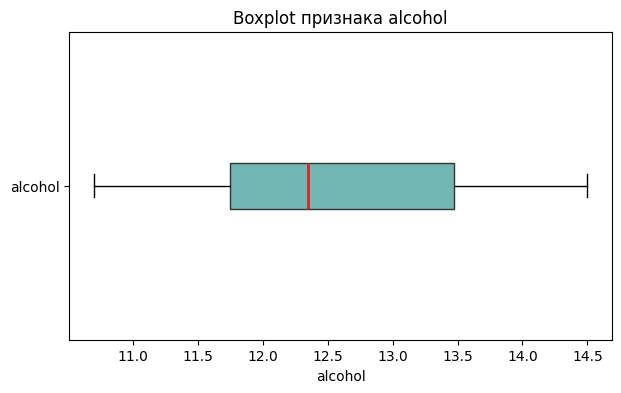

In [8]:
plt.figure(figsize=(7, 4))
plt.boxplot(
    alcohol_values,
    vert=False,
    patch_artist=True,
    boxprops={'facecolor': '#72b7b2', 'color': '#333333'},
    medianprops={'color': '#d62728', 'linewidth': 2},
)
plt.title('Boxplot признака alcohol')
plt.xlabel('alcohol')
plt.yticks([1], ['alcohol'])
plt.show()

## Вывод

В работе выполнено кодирование категориального признака `wine_type` методом count/frequency encoding. Для числового признака `alcohol` выполнено медианное масштабирование, после которого медиана нового признака равна нулю.